In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("training.csv")
df.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


In [2]:
print(df.shape)
print(df['Label'].value_counts())
print("\nMissing value placeholder (-999) counts:")
print((df == -999.000).sum().sum())

(250000, 33)
Label
b    164333
s     85667
Name: count, dtype: int64

Missing value placeholder (-999) counts:
1580052


In [3]:
# Replace -999 with NaN then fill with column median
features = df.drop(columns=['EventId', 'Weight', 'Label'])
features = features.replace(-999.0, np.nan)
features = features.fillna(features.median())

X = features
y = (df['Label'] == 's').astype(int)  # 1 for signal, 0 for background

print(X.shape)
print(y.value_counts())

(250000, 30)
Label
0    164333
1     85667
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)

print("Training done!")

Training done!


Accuracy: 0.8362
              precision    recall  f1-score   support

  Background       0.86      0.90      0.88     33065
      Signal       0.78      0.72      0.75     16935

    accuracy                           0.84     50000
   macro avg       0.82      0.81      0.81     50000
weighted avg       0.83      0.84      0.83     50000



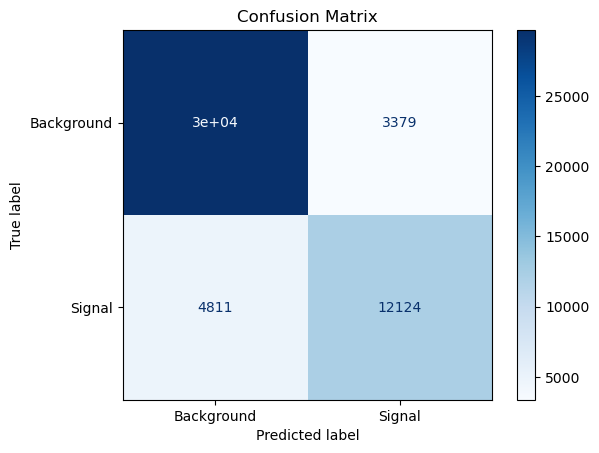

In [5]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Background', 'Signal']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Background', 'Signal'], cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

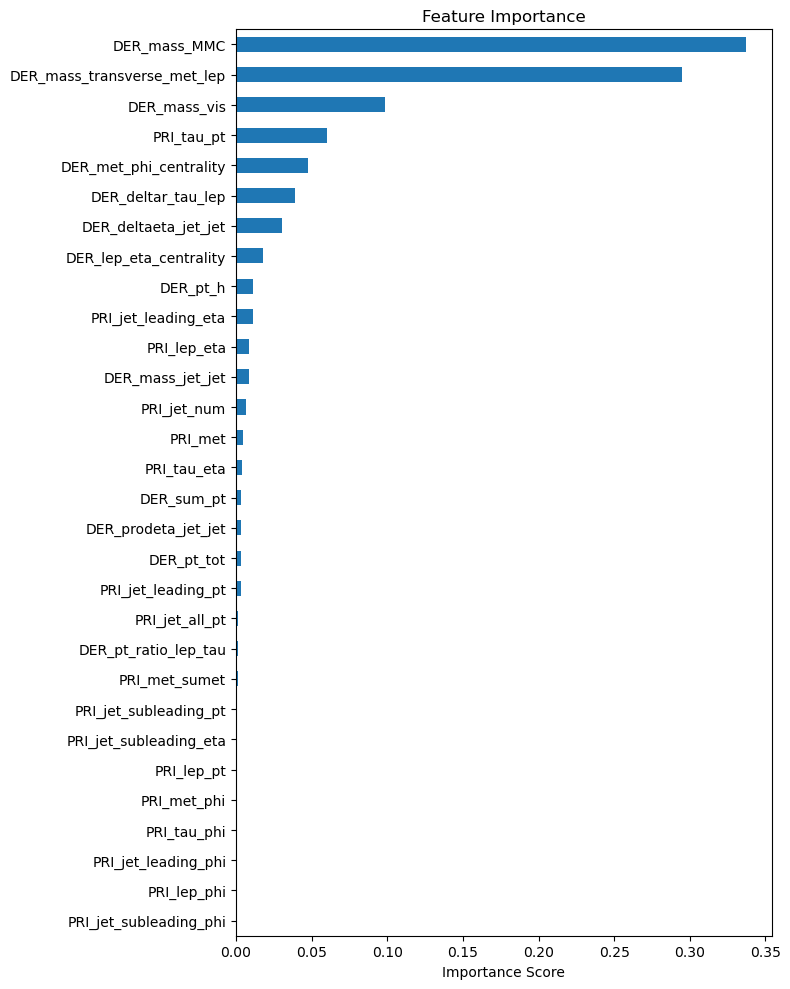

In [6]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 10))
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [7]:
# Load and preprocess test data
test_df = pd.read_csv("test.csv")
test_features = test_df.drop(columns=['EventId'])
test_features = test_features.replace(-999.0, np.nan)
test_features = test_features.fillna(test_features.median())

# Generate predictions
test_preds = model.predict(test_features)
test_labels = ['s' if p == 1 else 'b' for p in test_preds]

# Save to CSV
output = pd.DataFrame({'EventId': test_df['EventId'], 'Label': test_labels})
output.to_csv('predictions.csv', index=False)

print("Predictions saved!")
print(output['Label'].value_counts())

Predictions saved!
Label
b    378838
s    171162
Name: count, dtype: int64


In [8]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 36.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.
